In [1]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from numpy import asarray

In [2]:
# аналогичным образом загружаем данные о пассажирах
passengers = pd.read_csv('data/passengers.csv')
# неподходящий формат данных приводим к тому, с которым Pandas может работать
passengers['Month'] = pd.to_datetime(passengers['Month'])
# также устанавливаем индекс и сортируем
df = passengers.set_index('Month').sort_index()

In [3]:
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


## Предсказание временного ряда с помощью деревьев

Попробуем обычное дерево решений и случайный лес, а потом сравним результаты

In [4]:
cols = []
for i in range(1, 0, -1):
    cols.append(df.shift(i))
cols

[            Passengers
 Month                 
 1949-01-01         NaN
 1949-02-01       112.0
 1949-03-01       118.0
 1949-04-01       132.0
 1949-05-01       129.0
 ...                ...
 1960-08-01       622.0
 1960-09-01       606.0
 1960-10-01       508.0
 1960-11-01       461.0
 1960-12-01       390.0
 
 [144 rows x 1 columns]]

In [5]:
cols = []
for i in range(1, 0, -1):
    cols.append(df.shift(i))
for i in range(0, 1):
    cols.append(df.shift(-i))
cols

[            Passengers
 Month                 
 1949-01-01         NaN
 1949-02-01       112.0
 1949-03-01       118.0
 1949-04-01       132.0
 1949-05-01       129.0
 ...                ...
 1960-08-01       622.0
 1960-09-01       606.0
 1960-10-01       508.0
 1960-11-01       461.0
 1960-12-01       390.0
 
 [144 rows x 1 columns],
             Passengers
 Month                 
 1949-01-01         112
 1949-02-01         118
 1949-03-01         132
 1949-04-01         129
 1949-05-01         121
 ...                ...
 1960-08-01         606
 1960-09-01         508
 1960-10-01         461
 1960-11-01         390
 1960-12-01         432
 
 [144 rows x 1 columns]]

In [6]:
agg = pd.concat(cols, axis=1)
agg.dropna(inplace=True)
agg

,Passengers,Passengers
Month,,
1949-02-01,112.0,118
1949-03-01,118.0,132
1949-04-01,132.0,129
1949-05-01,129.0,121
1949-06-01,121.0,135
...,...,...
1960-08-01,622.0,606
1960-09-01,606.0,508
1960-10-01,508.0,461


In [7]:
n_vars = 1 if type(df) is list else df.shape[1]
cols = []
for i in range(1, 0, -1):
    cols.append(df.shift(i))
for i in range(0, 1):
    cols.append(df.shift(-i))
# put it all together
agg = pd.concat(cols, axis=1)
agg.dropna(inplace=True)
list_for_forecast = agg.values

In [8]:
len(list_for_forecast)

143

In [9]:
def decision_tree_forecast(train, testX):
    train = asarray(train)
    trainX, trainy = train[:, :-1], train[:, -1]
    model = DecisionTreeRegressor(random_state=0)
    model.fit(trainX, trainy)
    yhat = model.predict([testX])
    return yhat[0]

In [10]:
def random_forest_forecast(train, testX):
    train = asarray(train)
    trainX, trainy = train[:, :-1], train[:, -1]
    model = RandomForestRegressor(n_estimators=1000)
    model.fit(trainX, trainy)
    yhat = model.predict([testX])
    return yhat[0]

In [11]:
predictions = []
size = int(len(list_for_forecast) * 0.66)
train, test = list_for_forecast[0:size], list_for_forecast[size:len(list_for_forecast)]
history = [x for x in train]
history

[array([112., 118.]),
 array([118., 132.]),
 array([132., 129.]),
 array([129., 121.]),
 array([121., 135.]),
 array([135., 148.]),
 array([148., 148.]),
 array([148., 136.]),
 array([136., 119.]),
 array([119., 104.]),
 array([104., 118.]),
 array([118., 115.]),
 array([115., 126.]),
 array([126., 141.]),
 array([141., 135.]),
 array([135., 125.]),
 array([125., 149.]),
 array([149., 170.]),
 array([170., 170.]),
 array([170., 158.]),
 array([158., 133.]),
 array([133., 114.]),
 array([114., 140.]),
 array([140., 145.]),
 array([145., 150.]),
 array([150., 178.]),
 array([178., 163.]),
 array([163., 172.]),
 array([172., 178.]),
 array([178., 199.]),
 array([199., 199.]),
 array([199., 184.]),
 array([184., 162.]),
 array([162., 146.]),
 array([146., 166.]),
 array([166., 171.]),
 array([171., 180.]),
 array([180., 193.]),
 array([193., 181.]),
 array([181., 183.]),
 array([183., 218.]),
 array([218., 230.]),
 array([230., 242.]),
 array([242., 209.]),
 array([209., 191.]),
 array([19

In [12]:
train.dtype(list())

TypeError: 'numpy.dtypes.Float64DType' object is not callable

In [13]:
predictions = []
size = int(len(list_for_forecast) * 0.66)
train, test = list_for_forecast[0:size], list_for_forecast[size:len(list_for_forecast)]
history = [x for x in train]

for i in range(len(test)):
    testX, testy = test[i, :-1], test[i, -1]
    yhat = random_forest_forecast(history, testX)
    predictions.append(yhat)
    history.append(test[i])

error = mean_absolute_error(test[:, -1], predictions)
print("Random Forest error: ", error)

Random Forest error:  46.402645602526725


In [14]:
print("Random Forest metrics: ")
print("RMSE:", np.sqrt(mean_squared_error(test[:, -1], predictions)))
print("MAPE:", mean_absolute_percentage_error(test[:, -1], predictions))
print("MAE:", mean_absolute_error(test[:, -1], predictions))
print("R2: ", r2_score(test[:, -1], predictions))

Random Forest metrics: 
RMSE: 55.075398659767174
MAPE: 0.1091078059301739
MAE: 46.402645602526725
R2:  0.5060921897481744


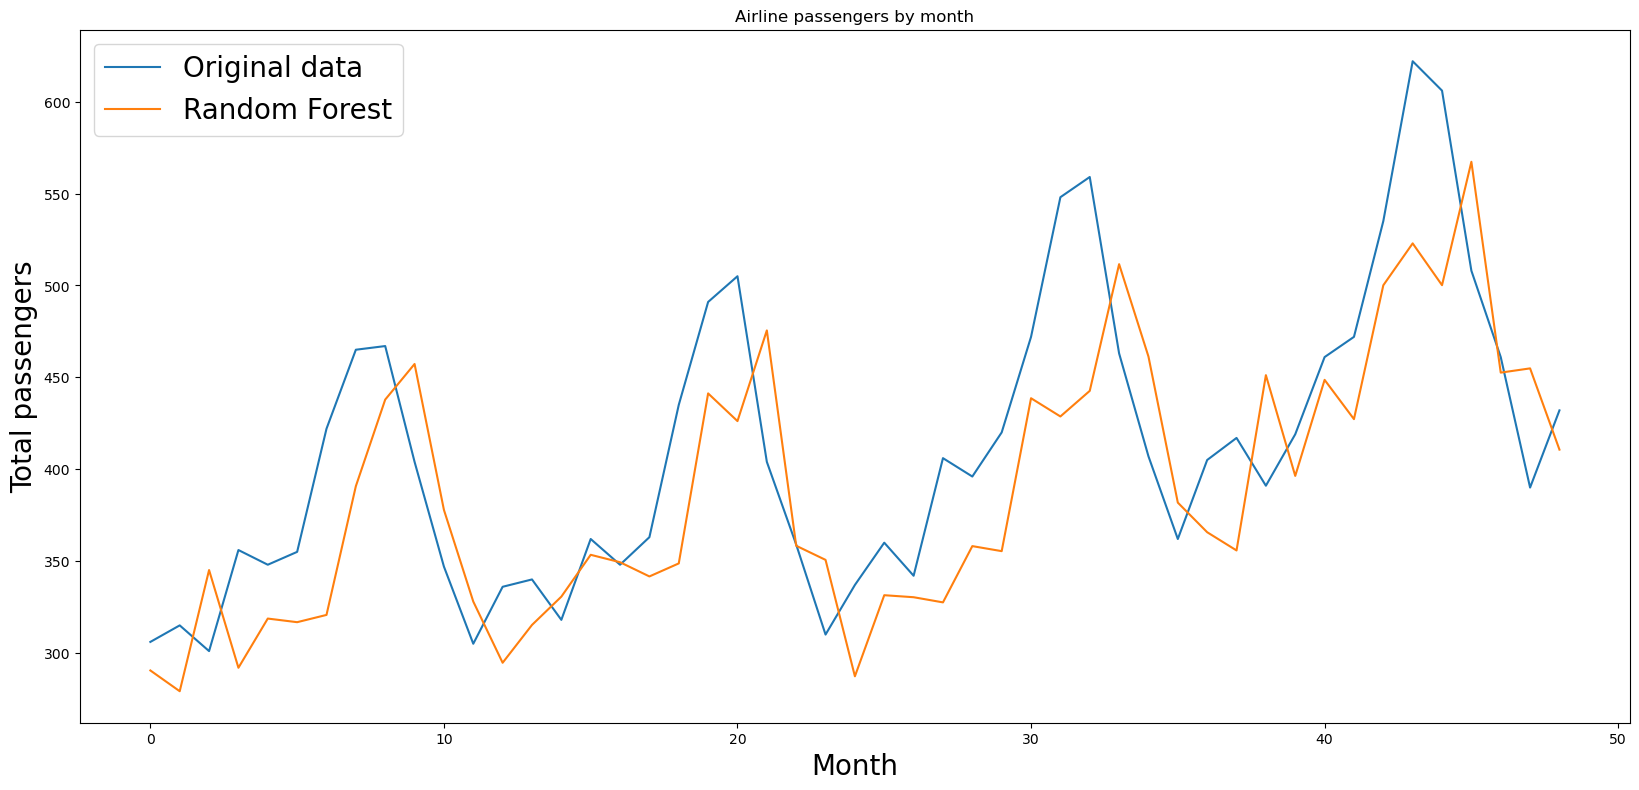

In [15]:
fig = plt.figure(figsize=(20, 9))
plt.plot(test[:, -1], label='Original data')
plt.plot(predictions, label='Random Forest')
plt.legend(fontsize="20")
plt.title('Airline passengers by month')
plt.ylabel('Total passengers', fontsize="20")
plt.xlabel('Month', fontsize="20")
plt.show()

In [16]:
predictions = list()
size = int(len(list_for_forecast) * 0.66)
train, test = list_for_forecast[0:size], list_for_forecast[size:len(list_for_forecast)]
history = [x for x in train]

for i in range(len(test)):
    testX, testy = test[i, :-1], test[i, -1]
    yhat = decision_tree_forecast(history, testX)
    predictions.append(yhat)
    history.append(test[i])


In [17]:
print("Decision Forest metrics: ")
print("RMSE:", np.sqrt(mean_squared_error(test[:, -1], predictions)))
print("MAPE:", mean_absolute_percentage_error(test[:, -1], predictions))
print("MAE:", mean_absolute_error(test[:, -1], predictions))
print("R2: ", r2_score(test[:, -1], predictions))

Decision Forest metrics: 
RMSE: 65.29403666867132
MAPE: 0.12270617535711836
MAE: 52.1530612244898
R2:  0.3058111520951716


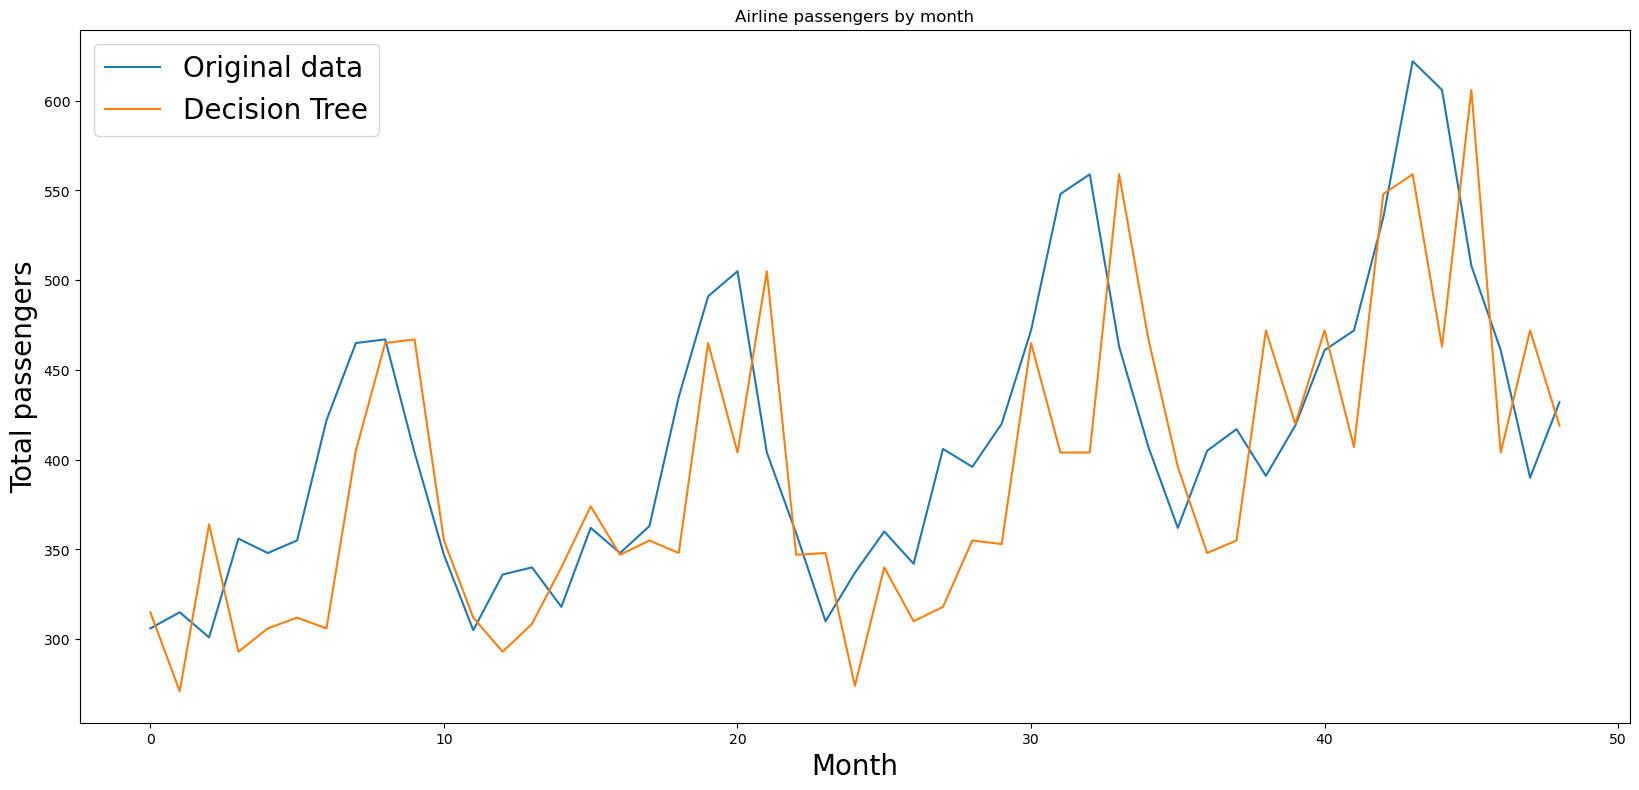

In [18]:
fig = plt.figure(figsize=(20, 9))
plt.plot(test[:, -1], label='Original data')
plt.plot(predictions, label='Decision Tree')
plt.legend(fontsize="20")
plt.title('Airline passengers by month')
plt.ylabel('Total passengers', fontsize="20")
plt.xlabel('Month', fontsize="20")
plt.show()

## Детекция аномалий с помощью isolated forest

In [19]:
from sklearn.ensemble import IsolationForest

In [20]:
# аналогичным образом загружаем данные о пассажирах
pas = pd.read_csv('data/passengers.csv')
# неподходящий формат данных приводим к тому, с которым Pandas может работать
pas['Month'] = pd.to_datetime(passengers['Month'])
# также устанавливаем индекс и сортируем
pas

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [21]:
model = IsolationForest(contamination=0.004)
model.fit(pas[['Passengers']])

IsolationForest(contamination=0.004)

In [22]:
pas['outliers'] = pd.Series(model.predict(pas[['Passengers']])).apply(lambda x: 'yes' if (x == -1) else 'no' )

In [23]:
pas.query('outliers=="yes"')

,Month,Passengers,outliers
138,1960-07-01,622,yes


In [24]:
fig = px.scatter(pas.reset_index(), x='Month', y='Passengers', color='outliers')
fig.update_xaxes(
    rangeslider_visible=True,
)
fig.show()

## Самостоятельная работа

**Задание 1: Учет сезонности (больше лагов)**
В нашем прошлом примере мы брали сдвиг всего на один месяц (`lag = 1`). В данных авиаперевозок есть очевидная годовая сезонность.
Измените код так, чтобы модель смотрела на 12 предыдущих месяцев одновременно. Сформируйте выборку, обучите `RandomForest` с помощью функции `random_forest_forecast` и выведите метрики. Сравните, как изменились результаты.


Random Forest с 12 лагами (учет годовой сезонности):
RMSE: 33.52319930204222
MAPE: 0.06297802138838167
MAE: 26.75437777777777
R2:  0.8072442771252465


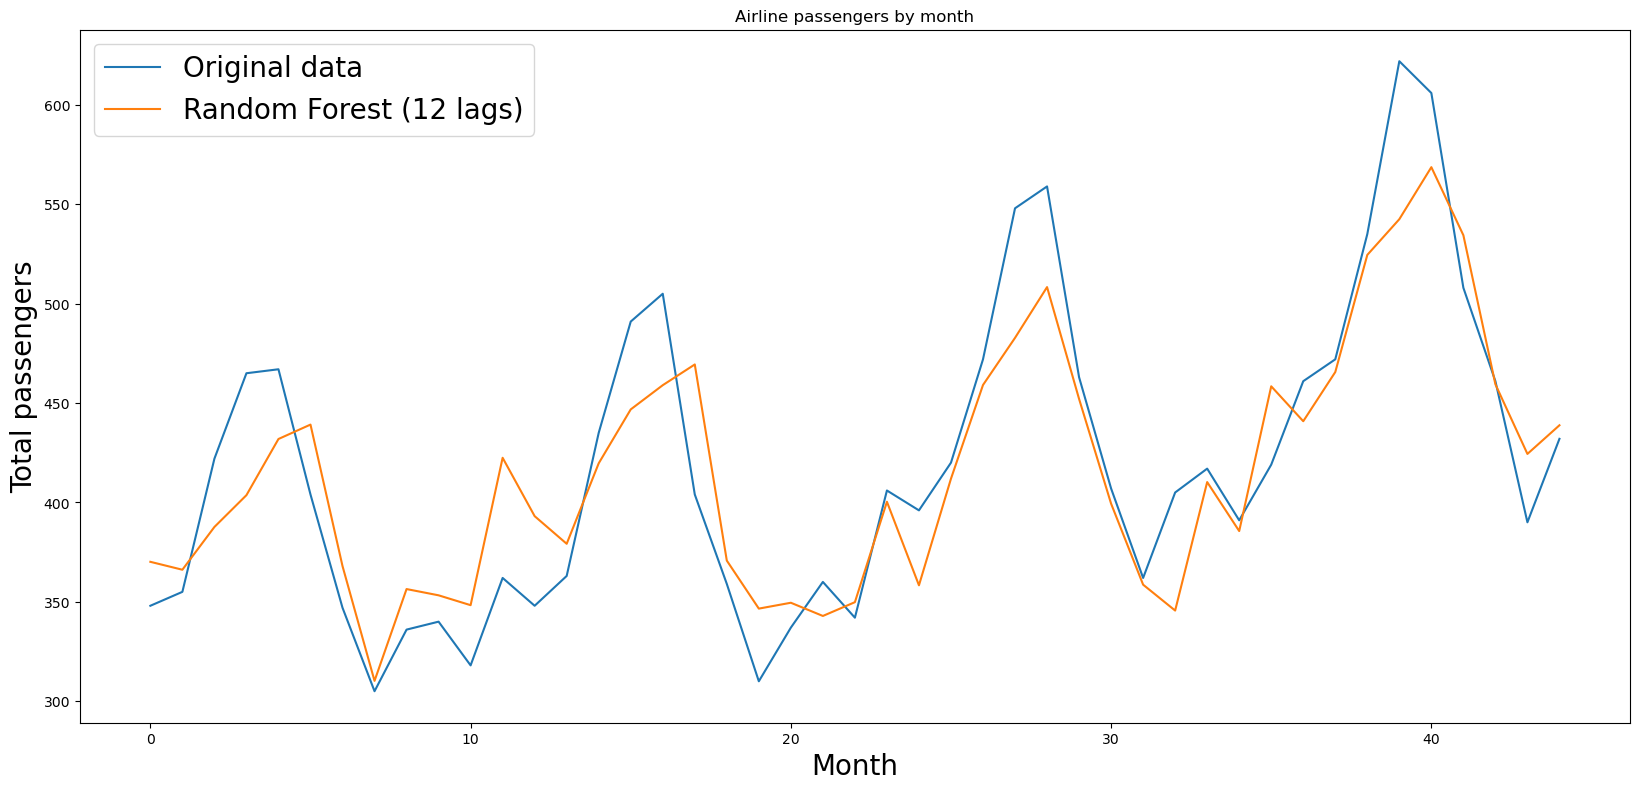

In [26]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from numpy import asarray

# Загружаем данные
passengers = pd.read_csv('data/passengers.csv')
passengers['Month'] = pd.to_datetime(passengers['Month'])
df = passengers.set_index('Month').sort_index()


cols = []
for i in range(12, 0, -1):      
    cols.append(df.shift(i))
for i in range(0, 1):
    cols.append(df.shift(-i))

# Формируем выборку
agg = pd.concat(cols, axis=1)
agg.dropna(inplace=True)

list_for_forecast = agg.values

# Функция random_forest_forecast 
def random_forest_forecast(train, testX):
    train = asarray(train)
    trainX, trainy = train[:, :-1], train[:, -1]
    model = RandomForestRegressor(n_estimators=1000)
    model.fit(trainX, trainy)
    yhat = model.predict([testX])
    return yhat[0]

# Прогнозирование
predictions = []
size = int(len(list_for_forecast) * 0.66)
train, test = list_for_forecast[0:size], list_for_forecast[size:len(list_for_forecast)]
history = [x for x in train]

for i in range(len(test)):
    testX, testy = test[i, :-1], test[i, -1]
    yhat = random_forest_forecast(history, testX)
    predictions.append(yhat)
    history.append(test[i])

# Вывод метрик
print("Random Forest с 12 лагами (учет годовой сезонности):")
print("RMSE:", np.sqrt(mean_squared_error(test[:, -1], predictions)))
print("MAPE:", mean_absolute_percentage_error(test[:, -1], predictions))
print("MAE:", mean_absolute_error(test[:, -1], predictions))
print("R2: ", r2_score(test[:, -1], predictions))

# Визуализация
fig = plt.figure(figsize=(20, 9))
plt.plot(test[:, -1], label='Original data')
plt.plot(predictions, label='Random Forest (12 lags)')
plt.legend(fontsize="20")
plt.title('Airline passengers by month')
plt.ylabel('Total passengers', fontsize="20")
plt.xlabel('Month', fontsize="20")
plt.show()

**Задание 2: Сравнение деревьев с «глупым» бейзлайном (Naive Forecast)**
Чтобы понимать, насколько вообще полезно применять Random Forest, нужен ориентир (baseline). Напишите простую «наивную» модель: в качестве прогноза на следующий шаг берется просто значение предыдущего шага ($\hat{y}_t = y_{t-1}$).
Сравните $R^2$ и $MAE$ наивного прогноза с вашим лесом из Задания 1.

In [27]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from numpy import asarray

# Загружаем данные
passengers = pd.read_csv('data/passengers.csv')
passengers['Month'] = pd.to_datetime(passengers['Month'])
df = passengers.set_index('Month').sort_index()

cols = []
for i in range(12, 0, -1):
    cols.append(df.shift(i))
for i in range(0, 1):
    cols.append(df.shift(-i))

agg = pd.concat(cols, axis=1)
agg.dropna(inplace=True)
list_for_forecast = agg.values

def random_forest_forecast(train, testX):
    train = asarray(train)
    trainX, trainy = train[:, :-1], train[:, -1]
    model = RandomForestRegressor(n_estimators=1000)
    model.fit(trainX, trainy)
    yhat = model.predict([testX])
    return yhat[0]

predictions_rf = []
size = int(len(list_for_forecast) * 0.66)
train, test = list_for_forecast[0:size], list_for_forecast[size:len(list_for_forecast)]
history = [x for x in train]

for i in range(len(test)):
    testX, testy = test[i, :-1], test[i, -1]
    yhat = random_forest_forecast(history, testX)
    predictions_rf.append(yhat)
    history.append(test[i])


actual = test[:, -1]
naive_predictions = []

# Для каждого элемента тестовой выборки прогноз = предыдущее фактическое значение
for i in range(len(actual)):
    if i == 0:
        # Для первого: предыдущее = последнее значение из train
        naive_predictions.append(train[-1, -1])
    else:
        # Для остальных: предыдущее = фактическое значение предыдущего тестового
        naive_predictions.append(actual[i-1])

# Сравнение метрик
print("Random Forest R2:", r2_score(actual, predictions_rf))
print("Random Forest MAE:", mean_absolute_error(actual, predictions_rf))
print()
print("Naive Forecast R2:", r2_score(actual, naive_predictions))
print("Naive Forecast MAE:", mean_absolute_error(actual, naive_predictions))

Random Forest R2: 0.8051203044503885
Random Forest MAE: 26.736755555555565

Naive Forecast R2: 0.59033250438754
Naive Forecast MAE: 40.977777777777774


**Задание 3: Чувствительность алгоритма поиска аномалий**
В конце практики мы использовали алгоритм `IsolationForest` для поиска аномалий с крайне низким параметром `contamination=0.004`.
Измените этот параметр на `0.05` (поиск 5% самых аномальных периодов), обучите модель заново и отрисуйте график с новыми подсвеченными точками. Как поменялась картина, какие теперь месяцы считаются "нетипичными"?


In [30]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.ensemble import IsolationForest

# Загружаем данные
passengers = pd.read_csv('data/passengers.csv')
passengers['Month'] = pd.to_datetime(passengers['Month'])
df = passengers.set_index('Month').sort_index()

# IsolationForest с contamination=0.05 
model = IsolationForest(
    contamination=0.05,
    random_state=42,
    bootstrap=True,     
    n_estimators=200    
)
model.fit(df[['Passengers']])

# Предсказываем аномалии (-1 = аномалия, 1 = норма)
df['outliers'] = model.predict(df[['Passengers']])

# Преобразуем для отображения
df['outliers_label'] = df['outliers'].apply(lambda x: 'yes' if x == -1 else 'no')

# Выводим аномальные месяцы
print("Аномальные месяцы (contamination=0.05):")
anomalies = df[df['outliers'] == -1]
print(anomalies[['Passengers']])
print(f"\nКоличество аномалий: {len(anomalies)}")

fig = px.scatter(df.reset_index(), x='Month', y='Passengers', color='outliers_label')
fig.update_xaxes(rangeslider_visible=True)
fig.show()

Аномальные месяцы (contamination=0.05):
            Passengers
Month                 
1949-11-01         104
1958-08-01         505
1959-07-01         548
1959-08-01         559
1960-06-01         535
1960-07-01         622
1960-08-01         606
1960-09-01         508

Количество аномалий: 8
